In [17]:
import torch
import torchvision
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

In [18]:
path = kagglehub.dataset_download("waalbannyantudre/hate-speech-detection-curated-dataset")

Using Colab cache for faster access to the 'hate-speech-detection-curated-dataset' dataset.


In [19]:
print(path)

/kaggle/input/hate-speech-detection-curated-dataset


In [20]:
import os
hate_speech_data = pd.read_csv(os.path.join(path, "HateSpeechDatasetBalanced.csv"))
print(hate_speech_data.head())
print(hate_speech_data['Label'].value_counts())

                                             Content  Label
0  denial of normal the con be asked to comment o...      1
1  just by being able to tweet this insufferable ...      1
2  that is retarded you too cute to be single tha...      1
3  thought of a real badass mongol style declarat...      1
4                                afro american basho      1
Label
1    364525
0    361594
Name: count, dtype: int64


In [21]:
!pip install transformers contractions emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 20.6 MB/s eta 0:00:00


In [22]:
import nltk, spacy, re, string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer, WordNetLemmatizer
import contractions
import emoji

nltk.download(['punkt_tab', 'wordnet', 'punkt', 'stopwords', 'averaged_perceptron_tagger'], quiet=True)

stemmer = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

punctuation_pattern = re.compile(f"[{re.escape(string.punctuation)}]")
digit_pattern = re.compile(r'\d+')
whitespace_pattern = re.compile(r'\s+')
non_word_pattern = re.compile(r'\W+')

def clean_text(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    text = text.lower()
    text = contractions.fix(text)
    text = digit_pattern.sub(' ', text)
    text = punctuation_pattern.sub(' ', text)
    text = non_word_pattern.sub(' ', text)
    text = whitespace_pattern.sub(' ', text).strip()
    text = emoji.demojize(text)
    return text

hate_speech_data['Cleaned_Content'] = hate_speech_data['Content'].apply(clean_text)

In [23]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(hate_speech_data, test_size=0.2, random_state=42, shuffle=True, stratify=hate_speech_data['Label'])

In [24]:
len(train_data), len(test_data)

(580895, 145224)

In [25]:
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import DistilBertModel, DistilBertTokenizer

from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from transformers import DataCollatorWithPadding


class HateSpeechDataset(Dataset):

    def __init__(self, tokenizer, data):
        self.tokenizer = tokenizer
        self.data = data


    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data.iloc[idx]
        text = item['Cleaned_Content']
        label = item['Label']
        encoding = self.tokenizer.encode_plus(text, padding='max_length', truncation=True, max_length=64, return_tensors='pt')
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"],
            "labels": label
        }


In [26]:

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')



Define Classifier model

In [27]:
class HateSpeechClassifier(nn.Module):
    def __init__(self, unfreeze_layers=6, dropout=0.4):
        super(HateSpeechClassifier, self).__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        for n, p in self.bert.named_parameters():
            p.requires_grad = False
        for param in self.bert.embeddings.parameters():
                param.requires_grad = True
        for layer in self.bert.transformer.layer[-unfreeze_layers:]:
            for p in layer.parameters():
                p.requires_grad = True
        self.pooling_dropout = nn.Dropout(dropout * 0.3)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.bert.config.hidden_size, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Dropout(dropout*0.7),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Dropout(dropout*0.4),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, attention_mask):
        last_hidden = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        last_hidden = self.pooling_dropout(last_hidden)
        mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        sum_embeddings = torch.sum(last_hidden * mask_expanded, 1)
        sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
        pooled = sum_embeddings / sum_mask
        # cls_embedding = outputs[:, 0, :]
        output = self.classifier(pooled)
        return output

In [28]:
train_dataset = HateSpeechDataset(tokenizer=tokenizer, data=train_data)
test_dataset = HateSpeechDataset(tokenizer=tokenizer, data=test_data)

from transformers import DataCollatorWithPadding, get_linear_schedule_with_warmup

# collator = DataCollatorWithPadding(tokenizer=tokenizer)

def collate_fn(batch):
    return {
        'input_ids': torch.stack([x['input_ids'] for x in batch]),
        'attention_mask': torch.stack([x['attention_mask'] for x in batch]),
        'labels': torch.tensor([x['labels'] for x in batch])
    }

batch_size = 64
num_epochs = 3
dataloader_train = DataLoader(train_dataset,
                              batch_size=batch_size,
                              shuffle=True,
                              num_workers=2,
                              collate_fn=collate_fn,
                              pin_memory=True)

dataloader_test = DataLoader(test_dataset,
                             batch_size=batch_size,
                             shuffle=False,
                             num_workers=2,
                             collate_fn=collate_fn,
                             pin_memory=True)
model = HateSpeechClassifier()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

num_training_steps = len(dataloader_train) * num_epochs
num_warmup_steps = int(0.1 * num_training_steps)
optimizer = torch.optim.AdamW([
    {'params': model.bert.parameters(), 'lr': 2e-5},
    {'params': model.classifier.parameters(), 'lr': 5e-4}
], weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

loss_fn = nn.BCEWithLogitsLoss()


In [29]:
for i, batch in enumerate(dataloader_train):
    print(batch['input_ids'])
    break

tensor([[  101,  2182,  2024,  ...,     0,     0,     0],
        [  101,  2145,  2038,  ...,     0,     0,     0],
        [  101, 14560,  2024,  ...,     0,     0,     0],
        ...,
        [  101,  2065,  2017,  ...,     0,     0,     0],
        [  101,  2023,  2003,  ...,     0,     0,     0],
        [  101,  2017,  2024,  ...,     0,     0,     0]])


In [30]:
from tqdm import tqdm
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
count_train = 0
count_test = 0
for epoch in range(num_epochs):
    print(f"epoch {epoch+1}/{num_epochs}")
    model.train()
    correct_train = 0
    total_train = 0
    total_train_loss = 0
    for i, batch in enumerate(tqdm(dataloader_train)):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Squeeze the attention mask to remove the extra dimension if present
        if attention_mask.dim() > 2:
            attention_mask = attention_mask.squeeze(1)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.squeeze(), labels.float())
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()
        # train_losses.append(loss.item())
        preds = (torch.sigmoid(outputs) > 0.5).long()  # threshold at 0.5
        preds = preds.view(-1)
        labels = labels.view(-1)
        correct_train += (preds == labels.long()).sum().item()
        total_train += labels.size(0)
        count_train += 1

    avg_train_loss = total_train_loss / len(dataloader_train)
    train_losses.append(avg_train_loss)

    train_accuracy = correct_train / total_train
    train_accuracies.append(train_accuracy)

    model.eval()
    total_test_loss = 0
    correct_test = 0
    total_test = 0
    preds = list()
    truths = list()
    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader_test)):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # If attention_mask has more than 2 dimensions, squeeze it
            if attention_mask.dim() > 2:
                attention_mask = attention_mask.squeeze()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.squeeze(), labels.float())
            total_test_loss += loss.item()
            # test_losses.append(loss.item())
            preds = (torch.sigmoid(outputs) > 0.5).long()
            preds = preds.view(-1)
            correct_test += (preds == labels.long()).sum().item()
            total_test += labels.size(0)
            count_test += 1

    avg_test_loss = total_test_loss / len(dataloader_test)
    test_losses.append(avg_test_loss)
    test_accuracy = correct_test / total_test
    test_accuracies.append(test_accuracy)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss}, Test Loss: {avg_test_loss}")
    print(f"Train Accuracy: {train_accuracy}, Test Accuracy: {test_accuracy}")

epoch 1/3


100%|██████████| 2270/2270 [03:58<00:00,  9.52it/s]


Epoch 1/3, Train Loss: 0.32786320212116665, Test Loss: 0.2529373689008967
Train Accuracy: 0.8519870200294374, Test Accuracy: 0.890878918085165
epoch 2/3


100%|██████████| 2270/2270 [03:57<00:00,  9.55it/s]


Epoch 2/3, Train Loss: 0.20788750836006592, Test Loss: 0.22439949402856407
Train Accuracy: 0.9124523364807754, Test Accuracy: 0.9047815788024018
epoch 3/3


100%|██████████| 2270/2270 [03:58<00:00,  9.52it/s]

Epoch 3/3, Train Loss: 0.14533333454994796, Test Loss: 0.23984594723611807
Train Accuracy: 0.9405417502302481, Test Accuracy: 0.9061863052938908


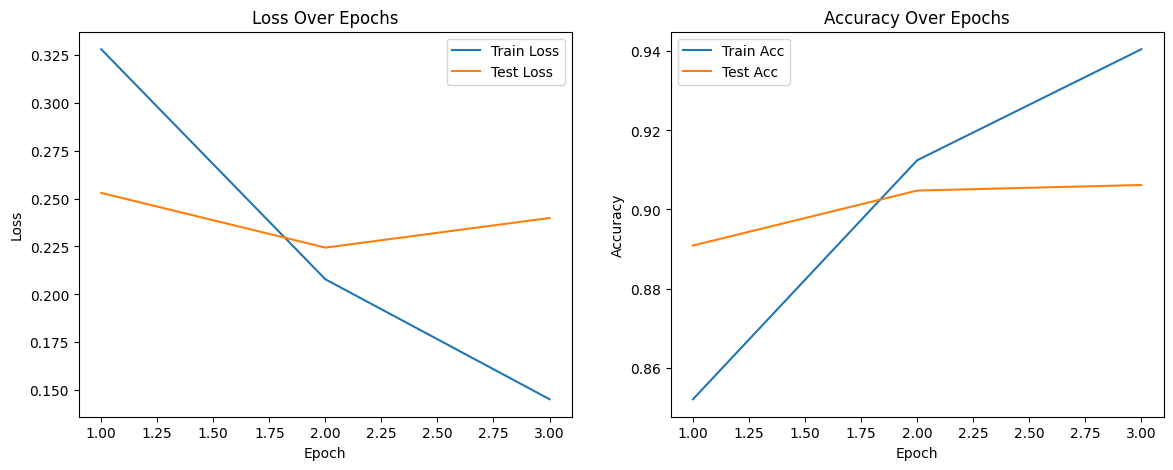

In [31]:

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# ---------- LOSS ----------
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()

# ---------- ACCURACY ----------
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Acc")
plt.plot(epochs, test_accuracies, label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Epochs")
plt.legend()

plt.show()

In [32]:
torch.save(model.state_dict(), 'hate_speech_model_weights.pth')

## Traditional Transformer method

In [33]:
from collections import Counter
import re

_basic_english_re = re.compile(r"[^a-zA-Z0-9']+")

def basic_english_tokenizer(text: str):
    """
    A close re-implementation of torchtext's basic_english tokenizer.
    - Lowercases text
    - Removes punctuation except apostrophes
    - Splits on whitespace
    """
    text = text.lower()

    # Replace all non alphanumerics/apostrophes with spaces
    text = _basic_english_re.sub(" ", text)

    # Split on whitespace
    tokens = text.strip().split()

    return tokens

def build_vocab_from_df(df, text_column="Content", min_freq=1):
    counter = Counter()
    for text in df[text_column]:
        tokens = basic_english_tokenizer(text)
        counter.update(tokens)

    vocab = {"<unk>": 0, "<pad>": 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

vocab = build_vocab_from_df(hate_speech_data, "Content")
tokenizer = basic_english_tokenizer

In [34]:
def text_pipeline(x):
    tokens = tokenizer(x)
    return [vocab[token] for token in tokens]

def get_text_lengths(data_iter):
    lengths = []
    for _, text in tqdm(data_iter):
        tokenized_text = tokenizer(text)
        lengths.append(len(tokenized_text))
    return np.array(lengths)

def collate_batch(batch, max_seq_len=256):
    labels, texts = zip(*batch)

    labels = torch.tensor(labels, dtype=torch.long) # Removed - 1

    encoded_texts = []
    for text in texts:
        ids = text_pipeline(text)              # token → index list

        if len(ids) > max_seq_len:
            ids = ids[:max_seq_len]
        else:
            pad_id = vocab["<pad>"]
            ids = ids + [pad_id] * (max_seq_len - len(ids))

        encoded_texts.append(torch.tensor(ids))

    encoded_texts = torch.stack(encoded_texts)   # (batch, seq_len)

    return encoded_texts, labels

In [35]:
class SimpleHateSpeechDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data.iloc[idx]['Label'], self.data.iloc[idx]['Content']

In [36]:
train_dataset = SimpleHateSpeechDataset(train_data)
test_dataset = SimpleHateSpeechDataset(test_data)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

label_counter = Counter()
for texts, labels in train_loader:
    label_counter.update(labels.tolist())
print("Label counts:", label_counter)

Label counts: Counter({1: 291620, 0: 289275})


In [37]:
class TransformerModel(torch.nn.Module):
    def __init__(self, vocab_size, embed_size, num_heads, num_encoder_layers, num_classes, dropout=0.1):

        super(TransformerModel, self).__init__()

        self.embedding = torch.nn.Embedding(vocab_size, embed_size)
        self.transformer = torch.nn.TransformerEncoder(
            torch.nn.TransformerEncoderLayer(embed_size, num_heads, embed_size * 2, dropout),
            num_encoder_layers
        )
        self.fc = torch.nn.Linear(embed_size, num_classes)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x)  # Embedding layer
        x = x.permute(1, 0, 2)  # Transformer expects (seq_len, batch_size, embedding_size)
        x = self.transformer(x)  # Apply transformer
        x = x.mean(dim=0)  # Pooling (take the mean of all tokens in the sequence)
        x = self.dropout(x)
        x = self.fc(x)  # Final classification layer
        return x

In [43]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# Initialize the model,
embed_size = 128
num_heads = 4
num_encoder_layers = 2
num_classes = 2
model2 = TransformerModel(len(vocab), embed_size, num_heads, num_encoder_layers, num_classes)

# Initialize loss function, and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)

model2.to(device)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


TransformerModel(
  (embedding): Embedding(136964, 128)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [44]:
num_epochs = 3
train_losses = np.zeros(num_epochs)
train_accuracies = np.zeros(num_epochs)

test_losses = np.zeros(num_epochs)
test_accuracies = np.zeros(num_epochs)

In [45]:
# YOUR CODE HERE
def train_epoch(model, train_loader, loss_fn, optimizer):
    model.train()
    epoch_loss = 0
    epoch_accuracy = 0
    # total_batches = 0
    total_batches = len(train_loader)

    for texts, labels in tqdm(train_loader):
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()

        # Forward pass
        outputs = model(texts)

        # Compute loss and gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Calculate accuracy
        preds = torch.argmax(outputs, dim=1)
        correct = (preds == labels).sum().item()
        accuracy = correct / labels.size(0)

        epoch_loss += loss.item()
        epoch_accuracy += accuracy

    return epoch_loss / total_batches, epoch_accuracy / total_batches

def evaluate(model, test_loader, loss_fn):
    model.eval()
    epoch_loss = 0
    epoch_accuracy = 0
    total_batches = len(test_loader)
    correct_preds = []
    incorrect_preds = []

    with torch.no_grad():
        for texts, labels in tqdm(test_loader):
            texts, labels = texts.to(device), labels.to(device)
            # Forward pass
            outputs = model(texts)

            # Compute loss
            loss = loss_fn(outputs, labels)

            # Calculate accuracy
            preds = torch.argmax(outputs, dim=1)
            correct_mask = preds == labels
            correct = (preds == labels).sum().item()
            accuracy = correct / labels.size(0)
            for i in range(len(labels)):
                if correct_mask[i]:
                    correct_preds.append((texts[i].cpu(), labels[i].cpu(), preds[i].cpu()))
                else:
                    incorrect_preds.append((texts[i].cpu(), labels[i].cpu(), preds[i].cpu()))
            epoch_loss += loss.item()
            epoch_accuracy += accuracy

    return epoch_loss / total_batches, epoch_accuracy / total_batches, correct_preds, incorrect_preds

In [46]:
# YOUR CODE HERE
def train_epoch(model, train_loader, loss_fn, optimizer):
    model.train()
    epoch_loss = 0
    epoch_accuracy = 0
    # total_batches = 0
    total_batches = len(train_loader)

    for texts, labels in tqdm(train_loader):
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()

        # Forward pass
        outputs = model(texts)

        # Compute loss and gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Calculate accuracy
        preds = torch.argmax(outputs, dim=1)
        correct = (preds == labels).sum().item()
        accuracy = correct / labels.size(0)

        epoch_loss += loss.item()
        epoch_accuracy += accuracy

    return epoch_loss / total_batches, epoch_accuracy / total_batches

def evaluate(model, test_loader, loss_fn):
    model.eval()
    epoch_loss = 0
    epoch_accuracy = 0
    total_batches = len(test_loader)
    correct_preds = []
    incorrect_preds = []

    with torch.no_grad():
        for texts, labels in tqdm(test_loader):
            texts, labels = texts.to(device), labels.to(device)
            # Forward pass
            outputs = model(texts)

            # Compute loss
            loss = loss_fn(outputs, labels)

            # Calculate accuracy
            preds = torch.argmax(outputs, dim=1)
            correct_mask = preds == labels
            correct = (preds == labels).sum().item()
            accuracy = correct / labels.size(0)
            for i in range(len(labels)):
                if correct_mask[i]:
                    correct_preds.append((texts[i].cpu(), labels[i].cpu(), preds[i].cpu()))
                else:
                    incorrect_preds.append((texts[i].cpu(), labels[i].cpu(), preds[i].cpu()))
            epoch_loss += loss.item()
            epoch_accuracy += accuracy

    return epoch_loss / total_batches, epoch_accuracy / total_batches, correct_preds, incorrect_preds

In [47]:
corr_preds_epochs = []
incorr_preds_epochs = []
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model2, train_loader, loss_fn, optimizer)
    train_losses[epoch] = train_loss
    train_accuracies[epoch] = train_acc

    test_loss, test_acc, correct_preds, incorrect_preds = evaluate(model2, test_loader, loss_fn)
    corr_preds_epochs.append(correct_preds)
    incorr_preds_epochs.append(incorrect_preds)
    test_losses[epoch] = test_loss
    test_accuracies[epoch] = test_acc

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

100%|██████████| 4539/4539 [00:56<00:00, 79.84it/s]


Epoch [1/3]
Train Loss: 0.4166, Train Acc: 0.8064
Test Loss: 0.3825, Test Acc: 0.8305


100%|██████████| 4539/4539 [00:56<00:00, 80.25it/s]


Epoch [2/3]
Train Loss: 0.3595, Train Acc: 0.8398
Test Loss: 0.3622, Test Acc: 0.8378


100%|██████████| 4539/4539 [00:57<00:00, 79.35it/s]

Epoch [3/3]
Train Loss: 0.3373, Train Acc: 0.8512
Test Loss: 0.3622, Test Acc: 0.8427


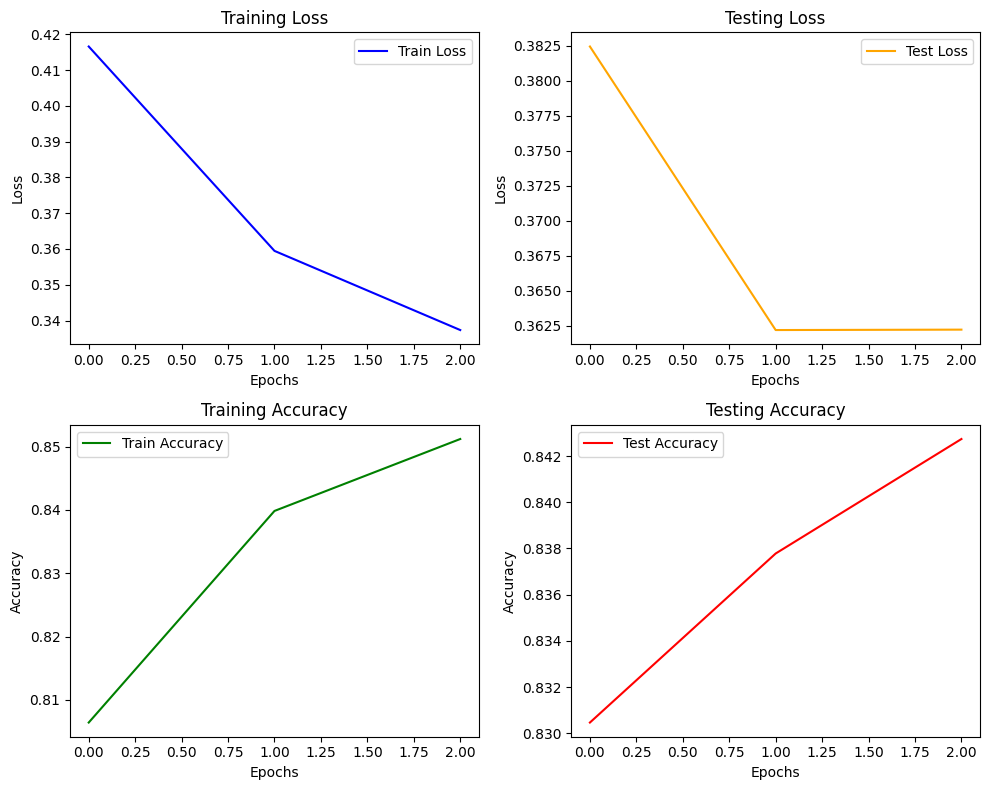

In [48]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

num_epochs = 3
epochs = list(range(0, num_epochs))

# Create 2x2 grid of subplots using plt.subplot
plt.figure(figsize=(10, 8))

# Training Loss
plt.subplot(2, 2, 1)  # (rows, columns, index)
plt.plot(epochs, train_losses, color='blue', label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Testing Loss
plt.subplot(2, 2, 2)
plt.plot(epochs, test_losses, color='orange', label='Test Loss')
plt.title('Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Training Accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, train_accuracies, color='green', label='Train Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Testing Accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, test_accuracies, color='red', label='Test Accuracy')
plt.title('Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Adjust layout and display
plt.tight_layout()
plt.show()

In [ ]:
torch.save(model2, 'hate_speech_base_model.pth')